Loaded 12 conditions from /home/quantum/ys_lee/Pauli-Propagation---GPU-acceleration/QAOA/artifacts/sweep_multi_graphs_minabs_only_oddneg/summary_partial.json


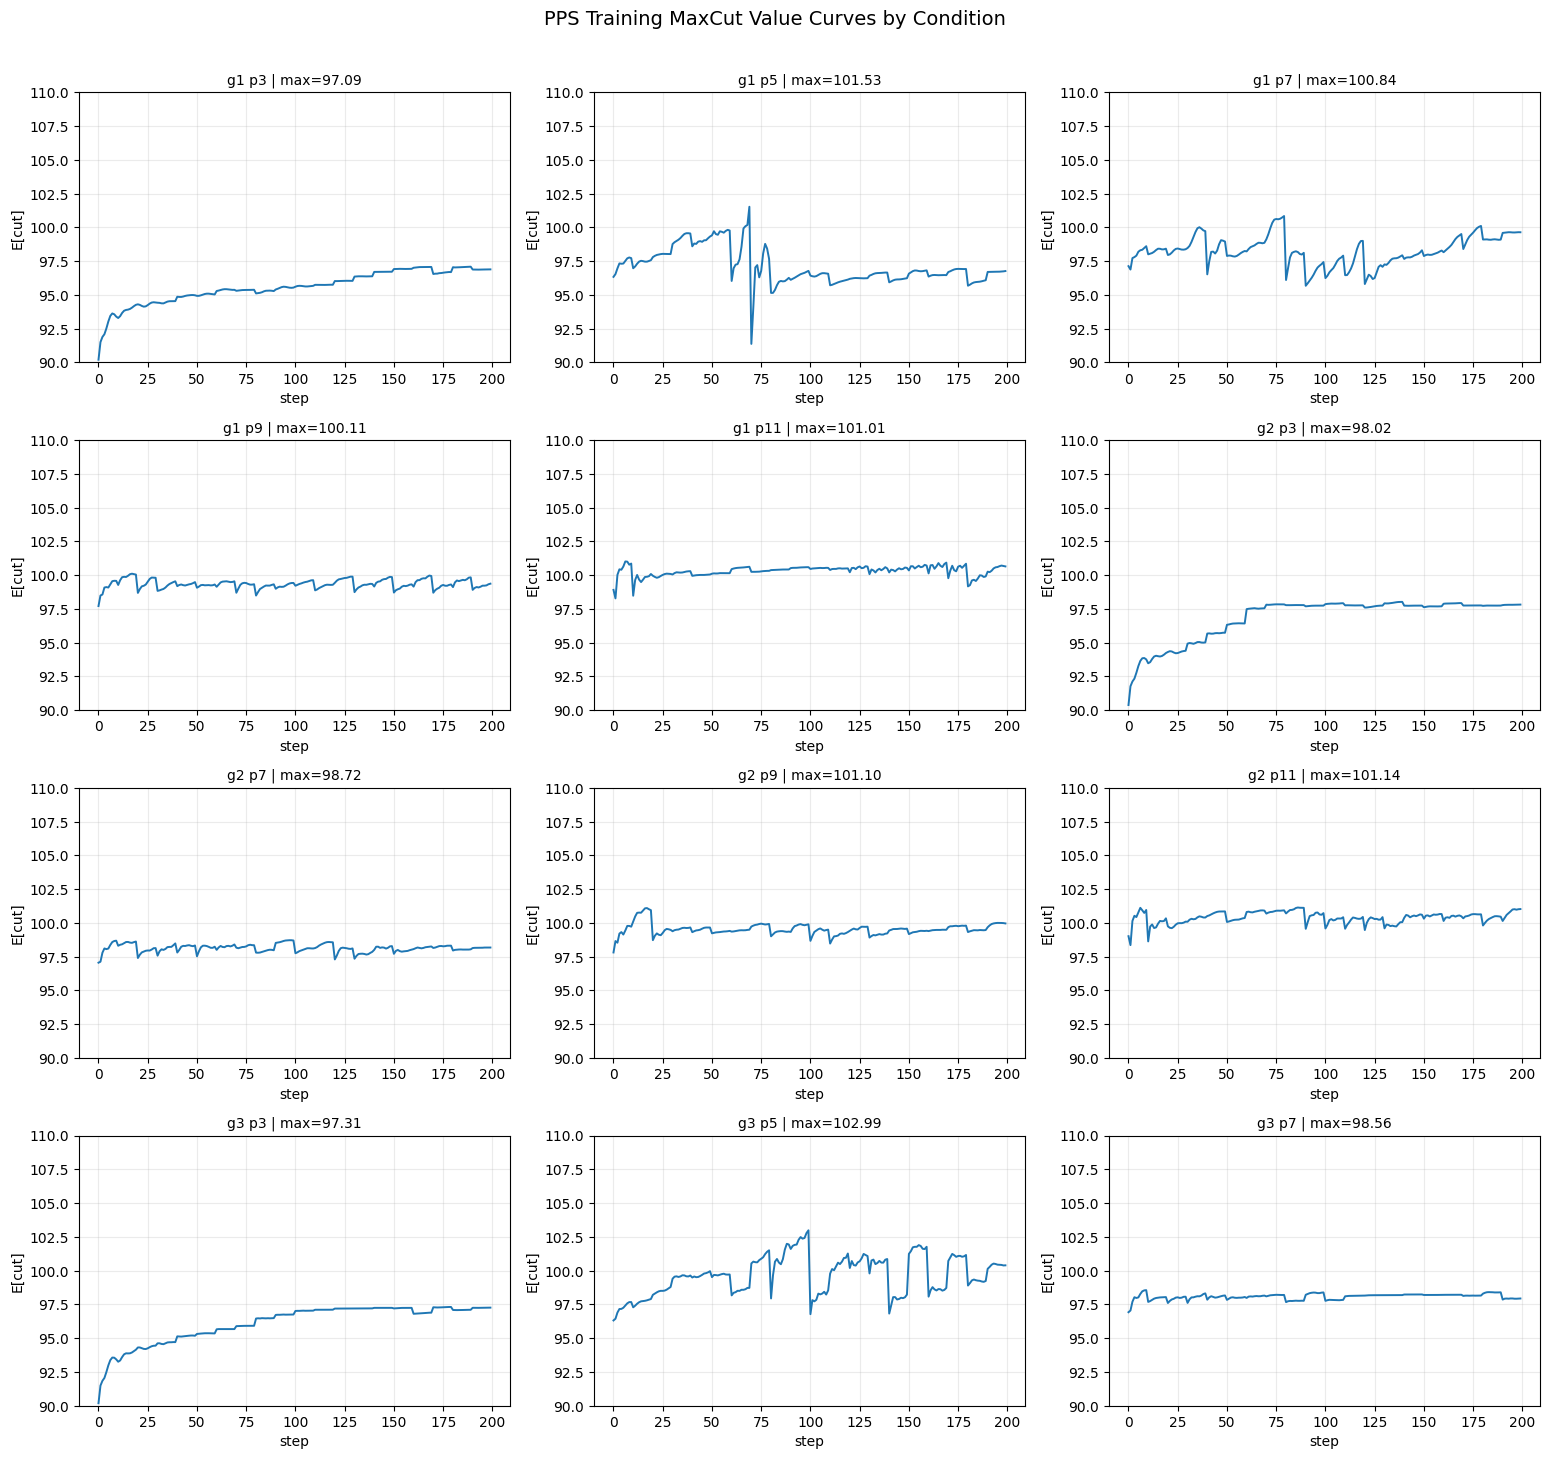

Saved per-condition plots: /home/quantum/ys_lee/Pauli-Propagation---GPU-acceleration/QAOA/artifacts/sweep_multi_graphs_minabs_only_oddneg/analysis/training_curves
Saved panel plot: /home/quantum/ys_lee/Pauli-Propagation---GPU-acceleration/QAOA/artifacts/sweep_multi_graphs_minabs_only_oddneg/analysis/training_curves/all_conditions_training_curves.png


In [2]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np

# 분석 대상 sweep 폴더 (작업 디렉터리에 따라 자동 해석)
sweep_rel = Path("QAOA/artifacts/sweep_multi_graphs_minabs_only_oddneg")
search_roots = [Path.cwd(), Path.cwd().parent, Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()]

sweep_dir = None
for root in search_roots:
    cand1 = (root / sweep_rel).resolve()
    cand2 = (root / "artifacts" / "sweep_multi_graphs_minabs_only_oddneg").resolve()
    for cand in (cand1, cand2):
        if cand.exists():
            sweep_dir = cand
            break
    if sweep_dir is not None:
        break

if sweep_dir is None:
    raise FileNotFoundError("Could not resolve sweep directory for sweep_multi_graphs_minabs_only_oddneg")

# summary 파일 자동 선택 (partial 우선)
summary_candidates = [
    sweep_dir / "summary_partial.json",
    sweep_dir / "summary.json",
]
summary_path = next((p for p in summary_candidates if p.exists()), None)
if summary_path is None:
    raise FileNotFoundError(f"summary file not found under: {sweep_dir}")

summary = json.loads(summary_path.read_text(encoding="utf-8"))
records = summary.get("records", [])
if not isinstance(records, list) or len(records) == 0:
    raise RuntimeError(f"No run records in summary: {summary_path}")

# 보고서 로드
rows = []
for rec in records:
    if not isinstance(rec, dict):
        continue
    if str(rec.get("status", "")) != "ok":
        continue

    report_path = Path(str(rec.get("report", ""))).resolve()
    if not report_path.exists():
        continue

    report = json.loads(report_path.read_text(encoding="utf-8"))
    hist = report.get("training", {}).get("history_expected_cut", [])
    if not isinstance(hist, list) or len(hist) == 0:
        continue

    rows.append(
        {
            "run_name": str(rec.get("run_name", report_path.stem)),
            "n_qubits": int(rec.get("n_qubits", report.get("config", {}).get("n_qubits", 0))),
            "p_layers": int(rec.get("p_layers", report.get("config", {}).get("p_layers", 0))),
            "graph_index": rec.get("graph_index", None),
            "weight_mode": rec.get("weight_mode", None),
            "max_weight": rec.get("max_weight", None),
            "anneal_best": rec.get("graph_anneal_best_cut", None),
            "history_expected_cut": [float(x) for x in hist],
            "best_expected_cut": float(report.get("training", {}).get("best_expected_cut", max(hist))),
            "report_path": str(report_path),
        }
    )

if len(rows) == 0:
    raise RuntimeError("No valid run reports found with training history.")

rows = sorted(rows, key=lambda r: (r["n_qubits"], r["graph_index"] if r["graph_index"] is not None else -1, r["p_layers"]))

print(f"Loaded {len(rows)} conditions from {summary_path}")

# 1) 조건별 개별 plot 저장
plot_dir = sweep_dir / "analysis" / "training_curves"
plot_dir.mkdir(parents=True, exist_ok=True)

for r in rows:
    y = np.asarray(r["history_expected_cut"], dtype=np.float64)
    x = np.arange(len(y), dtype=np.int64)

    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    ax.plot(x, y, linewidth=1.8, color="tab:blue", label="PPS expected cut")

    if r["anneal_best"] is not None:
        ax.axhline(float(r["anneal_best"]), linestyle="--", linewidth=1.2, color="tab:orange", label="SA best cut")

    ax.scatter([int(np.argmax(y))], [float(np.max(y))], color="tab:red", s=25, zorder=3, label="run max")

    title = (
        f"{r['run_name']}\n"
        f"q={r['n_qubits']}, p={r['p_layers']}, mode={r['weight_mode']}, mw={r['max_weight']}"
    )
    ax.set_title(title)
    ax.set_xlabel("training step")
    ax.set_ylabel("expected cut")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)

    out_png = plot_dir / f"{r['run_name']}_training_curve.png"
    fig.tight_layout()
    fig.savefig(out_png, dpi=140)
    plt.close(fig)

# 2) 전체 조건 비교용 멀티패널 plot
n_cols = 3
n_rows = math.ceil(len(rows) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 3.6 * n_rows), squeeze=False)

for i, r in enumerate(rows):
    ax = axes[i // n_cols][i % n_cols]
    y = np.asarray(r["history_expected_cut"], dtype=np.float64)
    x = np.arange(len(y), dtype=np.int64)
    ax.plot(x, y, linewidth=1.4, color="tab:blue")

    if r["anneal_best"] is not None:
        ax.axhline(float(r["anneal_best"]), linestyle="--", linewidth=1.0, color="tab:orange")

    ax.set_title(f"g{r['graph_index']} p{r['p_layers']} | max={float(np.max(y)):.2f}", fontsize=10)
    ax.set_xlabel("step")
    ax.set_ylabel("E[cut]")
    ax.grid(True, alpha=0.25)
    ax.set_ylim(90, 110)
# 남는 축 숨기기
for j in range(len(rows), n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis("off")

fig.suptitle("PPS Training MaxCut Value Curves by Condition", fontsize=14, y=1.01)
fig.tight_layout()

panel_png = plot_dir / "all_conditions_training_curves.png"
fig.savefig(panel_png, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved per-condition plots: {plot_dir}")
print(f"Saved panel plot: {panel_png}")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


if "multi_df" not in globals():
    raise RuntimeError("Run the previous multi-step comparison cell first (multi_df is missing).")

analysis_root = sweep_dir / "analysis"
out_dir = analysis_root

plot_df = multi_df.copy()
plot_df = plot_df[np.isfinite(plot_df["abs_gap"].to_numpy(dtype=np.float64))].copy()

if plot_df.empty:
    raise RuntimeError("No valid abs_gap rows found in multi_df.")

# 조건 키: run_name (graph/p 포함)
conditions = sorted(plot_df["run_name"].unique().tolist())

# 공통 step 축(숫자 step + final)
step_axis = (
    plot_df[["step_order", "used_step"]]
    .drop_duplicates()
    .sort_values("step_order")
    .reset_index(drop=True)
)
step_orders = step_axis["step_order"].to_numpy(dtype=np.int64)
step_labels = [str(v) for v in step_axis["used_step"].tolist()]

# 1) 조건별 gap 추세 패널 플롯
n_cond = len(conditions)
n_cols = 3
n_rows = int(np.ceil(n_cond / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 3.6 * n_rows), constrained_layout=True)
axes = np.asarray(axes).reshape(-1)

run_stats = []

for idx, run_name in enumerate(conditions):
    ax = axes[idx]
    sub = plot_df[plot_df["run_name"] == run_name].copy()
    sub = sub.sort_values("step_order")

    merged = step_axis.merge(
        sub[["step_order", "abs_gap", "pps_expected_cut", "sample_expected_cut", "p_layers", "graph_index"]],
        on="step_order",
        how="left",
    )

    x = np.arange(len(merged), dtype=np.float64)
    y_gap = merged["abs_gap"].to_numpy(dtype=np.float64)

    ax.plot(x, y_gap, marker="o", linewidth=1.7)
    ax.set_xticks(x)
    ax.set_xticklabels(step_labels, fontsize=8)
    ax.grid(True, alpha=0.3)

    p_layers = merged["p_layers"].dropna().iloc[0] if merged["p_layers"].notna().any() else "?"
    graph_index = merged["graph_index"].dropna().iloc[0] if merged["graph_index"].notna().any() else "?"
    ax.set_title(f"p={int(p_layers) if p_layers != '?' else '?'} / g={int(graph_index) if graph_index != '?' else '?'}", fontsize=10)
    ax.set_ylabel("|PPS - Sample|")

    valid = np.isfinite(y_gap)
    if valid.sum() >= 2:
        y0 = float(y_gap[valid][0])
        ylast = float(y_gap[valid][-1])
        delta = ylast - y0
        slope = float(np.polyfit(np.arange(valid.sum(), dtype=np.float64), y_gap[valid], 1)[0])
        max_gap = float(np.nanmax(y_gap))
    else:
        y0 = np.nan
        ylast = np.nan
        delta = np.nan
        slope = np.nan
        max_gap = np.nan

    run_stats.append(
        {
            "run_name": run_name,
            "p_layers": int(p_layers) if p_layers != "?" else np.nan,
            "graph_index": int(graph_index) if graph_index != "?" else np.nan,
            "start_gap": y0,
            "end_gap": ylast,
            "delta_gap": delta,
            "slope_gap": slope,
            "max_gap": max_gap,
        }
    )

for j in range(n_cond, len(axes)):
    axes[j].axis("off")

fig.suptitle("Condition-wise gap trend (each panel = one run condition)", fontsize=14)
out_panel = out_dir / "pps_vs_sample_gap_by_condition_panels.png"
fig.savefig(out_panel, dpi=170)
plt.show()

# 2) 악화 조건 랭킹 + p별 집계
run_stats_df = pd.DataFrame(run_stats).sort_values("delta_gap", ascending=False).reset_index(drop=True)

p_summary_df = (
    run_stats_df.groupby("p_layers", as_index=False)
    .agg(
        n_runs=("run_name", "count"),
        mean_start_gap=("start_gap", "mean"),
        mean_end_gap=("end_gap", "mean"),
        mean_delta_gap=("delta_gap", "mean"),
        mean_slope_gap=("slope_gap", "mean"),
        mean_max_gap=("max_gap", "mean"),
        max_max_gap=("max_gap", "max"),
    )
    .sort_values("mean_delta_gap", ascending=False)
    .reset_index(drop=True)
)

print("Top worsening conditions (delta_gap descending)")
display(run_stats_df.head(8))

print("\nBy p_layers summary")
display(p_summary_df)

# 간단 진단 코멘트 자동 생성
top_bad = run_stats_df.head(3)[["run_name", "p_layers", "graph_index", "delta_gap", "max_gap"]]
print("\nQuick diagnostic hints")
for _, rr in top_bad.iterrows():
    print(
        f"- run={rr['run_name']} (p={int(rr['p_layers'])}, g={int(rr['graph_index'])}) "
        f"delta_gap={rr['delta_gap']:.3f}, max_gap={rr['max_gap']:.3f}"
    )

if not p_summary_df.empty:
    worst_p = p_summary_df.iloc[0]
    print(
        f"- Most gap-worsening depth: p={int(worst_p['p_layers'])} "
        f"(mean_delta_gap={worst_p['mean_delta_gap']:.3f}, mean_max_gap={worst_p['mean_max_gap']:.3f})"
    )
    

# 저장
out_run_stats = out_dir / "pps_vs_sample_gap_condition_run_stats.csv"
out_p_summary = out_dir / "pps_vs_sample_gap_condition_p_summary.csv"
run_stats_df.to_csv(out_run_stats, index=False)
p_summary_df.to_csv(out_p_summary, index=False)

print(f"\nSaved condition panel plot: {out_panel}")
print(f"Saved run-level stats CSV: {out_run_stats}")
print(f"Saved p-level summary CSV: {out_p_summary}")

RuntimeError: Run the previous multi-step comparison cell first (multi_df is missing).